# Aramex Fuel Price — Exploratory Data Analysis

Target variables:
- `data/95.csv` — 95 octane petrol price
- `data/50ppm.csv` — 50ppm diesel price

All other CSVs in `data/` are treated as candidate feature/indicator series, each following the
project convention: one row per month, columns `date, value, source, notes`.


In [1]:
# --- Imports ---
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import DBD_1

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)

## Data Loading - Petrol

In [4]:
master_petrol_df = DBD_1.load_petrol()
#master_petrol_df["Total_Production_Lag1"] = master_petrol_df["Total_Production"].shift(-1)


/Users/emmadevilliers/Documents/GitHub/fools-optimum/notebooks/DBD_1.py:49: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [5]:
master_petrol_df.head()

,Date,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,Brent_LastWeekStd,...,GSCPI_Lag6,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12
0,2011-01-01,872.8,453.949,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,0.932393,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-02-01,898.8,479.949,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,4.277731,...,NaN,NaN,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN
2,2011-03-01,941.8,522.949,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,0.556729,...,NaN,NaN,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN
3,2011-04-01,996.4,552.149,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,1.233450,...,NaN,NaN,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN
4,2011-05-01,1025.4,581.149,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,2.422369,...,NaN,NaN,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN


## Data Loading - Diesel

In [6]:
master_diesel_df = DBD_1.load_diesel()
#master_diesel_df["Total_Production_Lag1"] = master_diesel_df["Total_Production"].shift(-1)

/Users/emmadevilliers/Documents/GitHub/fools-optimum/notebooks/DBD_1.py:49: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [7]:
master_diesel_df.head()

,Date,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,Brent_LastWeekStd,...,GSCPI_Lag6,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12
0,2011-01-01,789.451,477.03,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,0.932393,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2011-02-01,821.451,509.03,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,4.277731,...,NaN,NaN,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN
2,2011-03-01,884.451,572.03,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,0.556729,...,NaN,NaN,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN
3,2011-04-01,953.851,616.03,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,1.233450,...,NaN,NaN,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN
4,2011-05-01,969.851,632.03,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,2.422369,...,NaN,NaN,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN


## Data overview - Petrol

In [8]:
print("Shape:", master_petrol_df.shape)
print("\nDate range:", master_petrol_df.index.min(), "to", master_petrol_df.index.max())
master_petrol_df.dtypes


Shape: (187, 60)

Date range: 0 to 186


Date                        datetime64[us]
Total_Fuel_Price                   float64
BFP                                float64
USDZAR_Mean                        float64
USDZAR_Std                         float64
USDZAR_LastWeekMean                float64
Brent_MonthMean                    float64
Brent_MonthStd                     float64
Brent_LastWeekMean                 float64
Brent_LastWeekStd                  float64
GPR                                float64
GSCPI                              float64
GECON                              float64
INDPRO                             float64
GPR_Lag1                           float64
GPR_Lag2                           float64
GPR_Lag3                           float64
GPR_Lag6                           float64
GPR_Lag12                          float64
BFP_Lag1                           float64
BFP_Lag2                           float64
BFP_Lag3                           float64
BFP_Lag6                           float64
BFP_Lag12  

In [9]:
# --- Missing values ---
missing = master_petrol_df.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0]

INDPRO_Lag12                6.417112
GPR_Lag12                   6.417112
BFP_Lag12                   6.417112
GSCPI_Lag12                 6.417112
BFP_Delta_Lag6              3.743316
GSCPI_Lag6                  3.208556
BFP_Delta_Lag5              3.208556
INDPRO_Lag6                 3.208556
BFP_Lag6                    3.208556
GPR_Lag6                    3.208556
BFP_Delta_Lag4              2.673797
BFP_Delta_Lag3              2.139037
Brent_LastWeekMean_Lag3     1.604278
Brent_MonthMean_Lag3        1.604278
USDZAR_LastWeekMean_Lag3    1.604278
BFP_Delta_Lag2              1.604278
USDZAR_Mean_Lag3            1.604278
BFP_Lag3                    1.604278
Brent_LastWeekStd_Lag3      1.604278
GPR_Lag3                    1.604278
USDZAR_Delta_Lag2           1.604278
INDPRO_Lag3                 1.604278
GSCPI_Lag3                  1.604278
GECON_Lag3                  1.604278
BFP_Delta_Lag1              1.069519
GECON_Lag2                  1.069519
Brent_LastWeekStd_Lag2      1.069519
I

In [10]:
# --- Summary statistics ---
master_petrol_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,187,2018-10-01 02:41:42.673796,2011-01-01 00:00:00,2014-11-16 00:00:00,2018-10-01 00:00:00,2022-08-16 12:00:00,2026-07-01 00:00:00,NaN
Total_Fuel_Price,187.0,1635.493134,872.8,1287.2,1458.7,2137.75,2806.2,466.348957
BFP,187.0,809.028316,274.77,596.87,718.17,984.97,1689.41,284.968657
USDZAR_Mean,187.0,13.866727,6.802743,11.203592,14.343967,16.715267,19.02058,3.483735
USDZAR_Std,187.0,0.255142,0.070746,0.154492,0.224506,0.298814,1.004549,0.138667
USDZAR_LastWeekMean,187.0,13.884941,6.744229,11.340329,14.309957,16.870229,19.5384,3.472803
Brent_MonthMean,187.0,77.891763,19.534643,59.99,75.251724,102.405517,125.02931,24.599728
Brent_MonthStd,187.0,3.207842,0.729977,1.892888,2.604776,3.694543,18.498657,2.258449
Brent_LastWeekMean,187.0,77.835633,15.92,60.036429,75.064286,101.263571,124.93,24.768364
Brent_LastWeekStd,187.0,1.444915,0.187388,0.8128,1.218807,1.578743,8.482695,1.138006


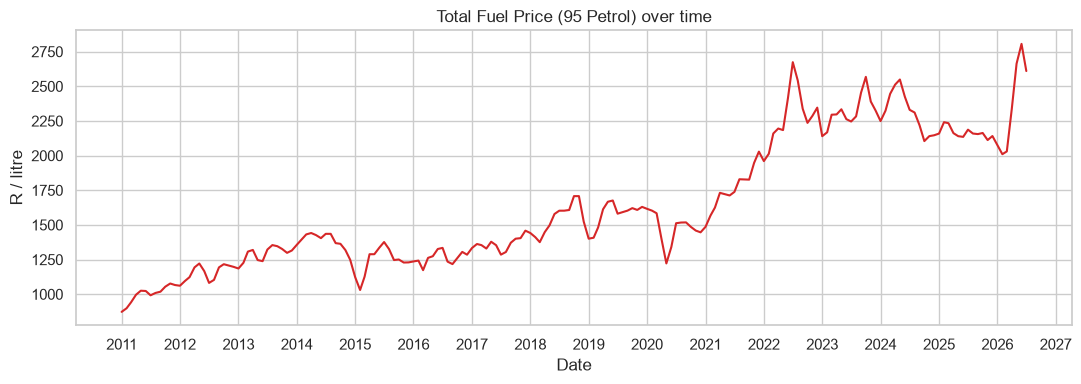

In [30]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(master_petrol_df["Date"], master_petrol_df["Total_Fuel_Price"], color="tab:red")
ax.set_title("Total Fuel Price (95 Petrol) over time")
ax.set_ylabel("R / litre")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")   # <-- replaces fig.autofmt_xdate()
plt.tight_layout()
plt.show()

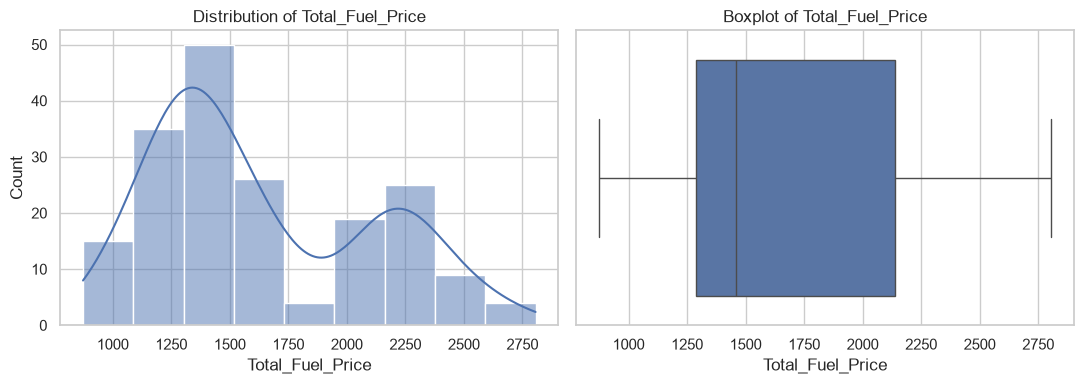

In [12]:
# --- Distribution of target ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(master_petrol_df["Total_Fuel_Price"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Total_Fuel_Price")

sns.boxplot(x=master_petrol_df["Total_Fuel_Price"], ax=axes[1])
axes[1].set_title("Boxplot of Total_Fuel_Price")
plt.tight_layout()
plt.show()

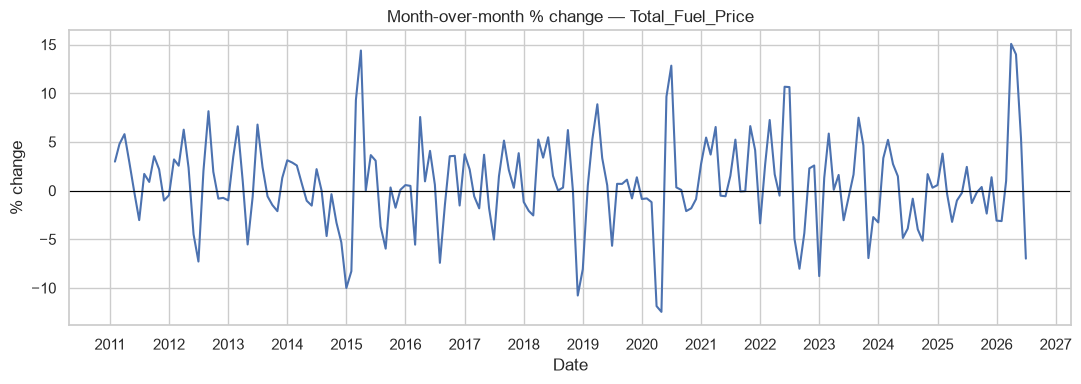

count    186.000000
mean       0.694955
std        4.595505
min      -12.455236
25%       -1.520379
50%        0.519771
75%        3.181599
max       15.071664
Name: Total_Fuel_Price, dtype: float64

In [31]:
# --- Month-over-month % change (volatility) ---
mom_change = master_petrol_df.set_index("Date")["Total_Fuel_Price"].pct_change() * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(mom_change.index, mom_change.values)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Month-over-month % change — Total_Fuel_Price")
ax.set_ylabel("% change")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
plt.tight_layout()
plt.show()

mom_change.describe()

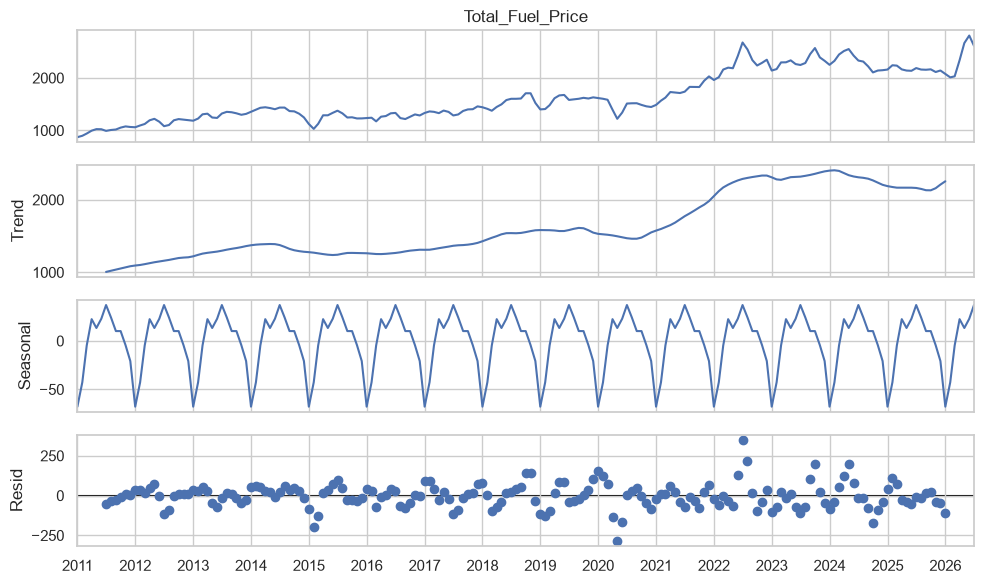

In [33]:
# --- Seasonal decomposition ---
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates

s = master_petrol_df.set_index("Date")["Total_Fuel_Price"].dropna()
result = seasonal_decompose(s, model="additive", period=12)
fig = result.plot()
fig.set_size_inches(10, 6)

for ax in fig.axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

plt.tight_layout()
plt.show()

In [15]:
# --- Correlation with other columns/features ---
corr = master_petrol_df.corr(numeric_only=True)["Total_Fuel_Price"].sort_values(ascending=False)
corr

Total_Fuel_Price            1.000000
BFP                         0.917838
BFP_Lag1                    0.900064
BFP_Lag2                    0.857644
BFP_Lag3                    0.822322
USDZAR_LastWeekMean         0.812334
USDZAR_Mean                 0.811120
USDZAR_LastWeekMean_Lag1    0.805851
USDZAR_Mean_Lag1            0.804844
USDZAR_LastWeekMean_Lag2    0.798525
USDZAR_Mean_Lag2            0.797915
USDZAR_LastWeekMean_Lag3    0.792261
USDZAR_Mean_Lag3            0.791495
BFP_Lag6                    0.786299
BFP_Lag12                   0.701335
GPR_Lag3                    0.583996
GPR_Lag2                    0.582006
GPR_Lag1                    0.570546
GPR                         0.552641
GPR_Lag6                    0.509350
GSCPI_Lag12                 0.432084
GPR_Lag12                   0.422158
INDPRO                      0.392220
INDPRO_Lag1                 0.385439
INDPRO_Lag2                 0.352419
INDPRO_Lag3                 0.324749
GSCPI_Lag6                  0.312529
I

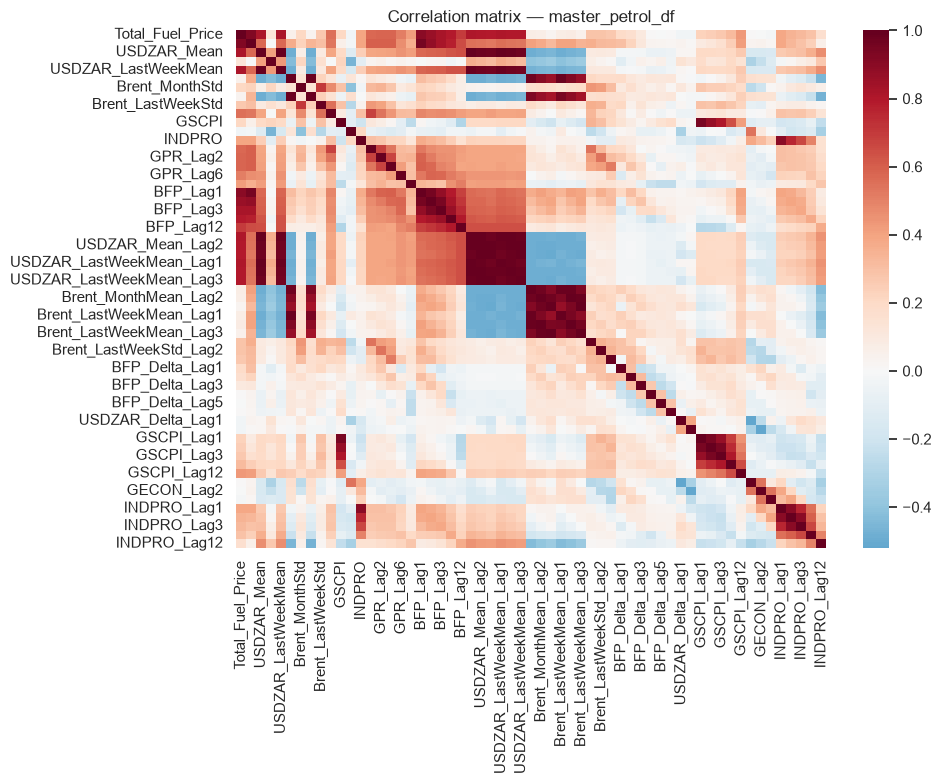

In [16]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(master_petrol_df.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — master_petrol_df")
plt.tight_layout()
plt.show()

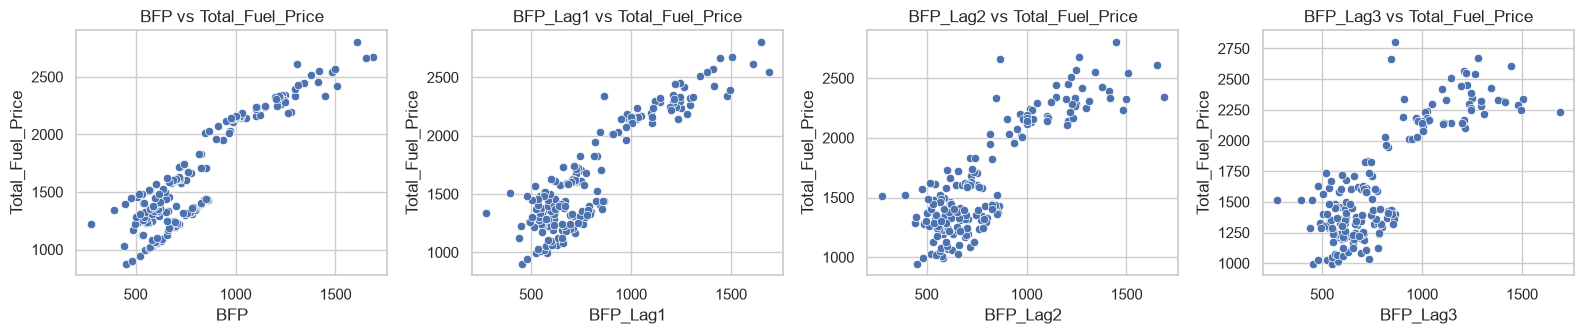

In [17]:
# --- Scatter plots: top correlated features vs target ---
top_feats = corr.drop("Total_Fuel_Price").abs().sort_values(ascending=False).head(4).index

fig, axes = plt.subplots(1, len(top_feats), figsize=(4 * len(top_feats), 3.5))
for ax, feat in zip(axes, top_feats):
    sns.scatterplot(x=master_petrol_df[feat], y=master_petrol_df["Total_Fuel_Price"], ax=ax)
    ax.set_title(f"{feat} vs Total_Fuel_Price")
plt.tight_layout()
plt.show()

## Data Overview - Diesel

In [18]:
print("Shape:", master_diesel_df.shape)
print("\nDate range:", master_diesel_df.index.min(), "to", master_diesel_df.index.max())
master_diesel_df.dtypes

Shape: (187, 60)

Date range: 0 to 186


Date                        datetime64[us]
Total_Fuel_Price                   float64
BFP                                float64
USDZAR_Mean                        float64
USDZAR_Std                         float64
USDZAR_LastWeekMean                float64
Brent_MonthMean                    float64
Brent_MonthStd                     float64
Brent_LastWeekMean                 float64
Brent_LastWeekStd                  float64
GPR                                float64
GSCPI                              float64
GECON                              float64
INDPRO                             float64
GPR_Lag1                           float64
GPR_Lag2                           float64
GPR_Lag3                           float64
GPR_Lag6                           float64
GPR_Lag12                          float64
BFP_Lag1                           float64
BFP_Lag2                           float64
BFP_Lag3                           float64
BFP_Lag6                           float64
BFP_Lag12  

In [19]:
# --- Summary statistics ---
master_diesel_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,187,2018-10-01 02:41:42.673796,2011-01-01 00:00:00,2014-11-16 00:00:00,2018-10-01 00:00:00,2022-08-16 12:00:00,2026-07-01 00:00:00,NaN
Total_Fuel_Price,187.0,1497.996385,789.451,1137.88,1316.82,1884.66,3230.0,476.590955
BFP,187.0,858.985952,367.03,602.03,750.03,1044.03,2606.1,358.049736
USDZAR_Mean,187.0,13.866727,6.802743,11.203592,14.343967,16.715267,19.02058,3.483735
USDZAR_Std,187.0,0.255142,0.070746,0.154492,0.224506,0.298814,1.004549,0.138667
USDZAR_LastWeekMean,187.0,13.884941,6.744229,11.340329,14.309957,16.870229,19.5384,3.472803
Brent_MonthMean,187.0,77.891763,19.534643,59.99,75.251724,102.405517,125.02931,24.599728
Brent_MonthStd,187.0,3.207842,0.729977,1.892888,2.604776,3.694543,18.498657,2.258449
Brent_LastWeekMean,187.0,77.835633,15.92,60.036429,75.064286,101.263571,124.93,24.768364
Brent_LastWeekStd,187.0,1.444915,0.187388,0.8128,1.218807,1.578743,8.482695,1.138006


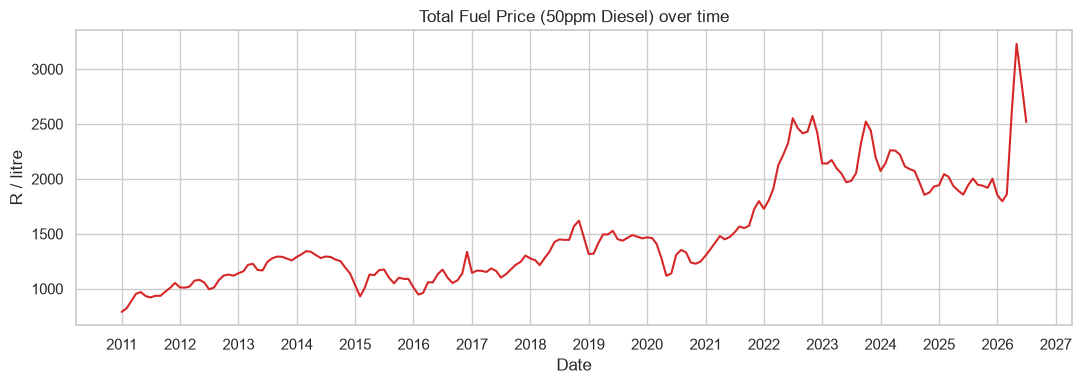

In [34]:
# --- Target variable over time ---
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(master_diesel_df["Date"], master_diesel_df["Total_Fuel_Price"], color="tab:red")
ax.set_title("Total Fuel Price (50ppm Diesel) over time")
ax.set_ylabel("R / litre")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")   # <-- replaces fig.autofmt_xdate()
plt.tight_layout()
plt.show()

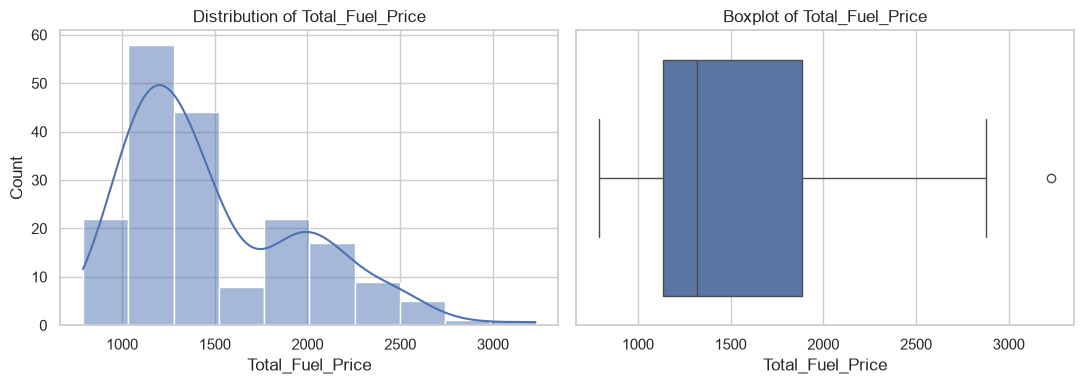

In [22]:
# --- Distribution of target ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(master_diesel_df["Total_Fuel_Price"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Total_Fuel_Price")

sns.boxplot(x=master_diesel_df["Total_Fuel_Price"], ax=axes[1])
axes[1].set_title("Boxplot of Total_Fuel_Price")
plt.tight_layout()
plt.show()

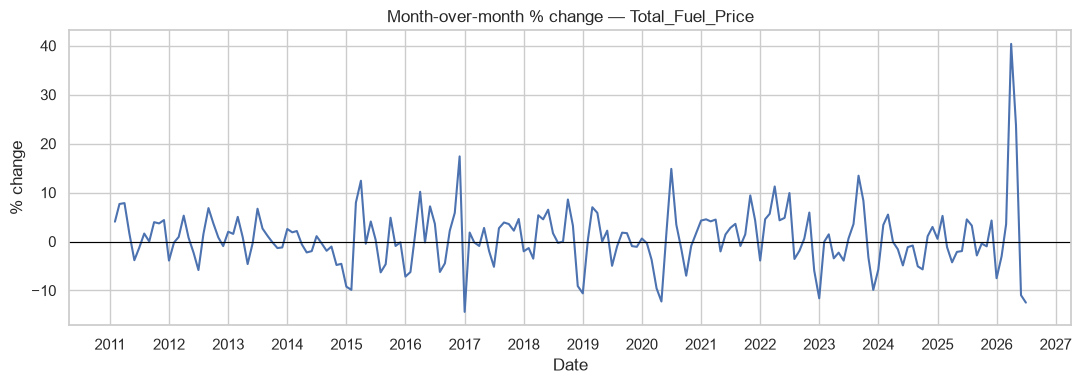

count    186.000000
mean       0.802163
std        6.132306
min      -14.368784
25%       -2.019470
50%        0.613119
75%        3.845528
max       40.371352
Name: Total_Fuel_Price, dtype: float64

In [ ]:

# --- Month-over-month % change (volatility) ---
mom_change = master_diesel_df.set_index("Date")["Total_Fuel_Price"].pct_change() * 100

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(mom_change.index, mom_change.values)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Month-over-month % change — Total_Fuel_Price")
ax.set_ylabel("% change")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
plt.tight_layout()
plt.show()

mom_change.describe()

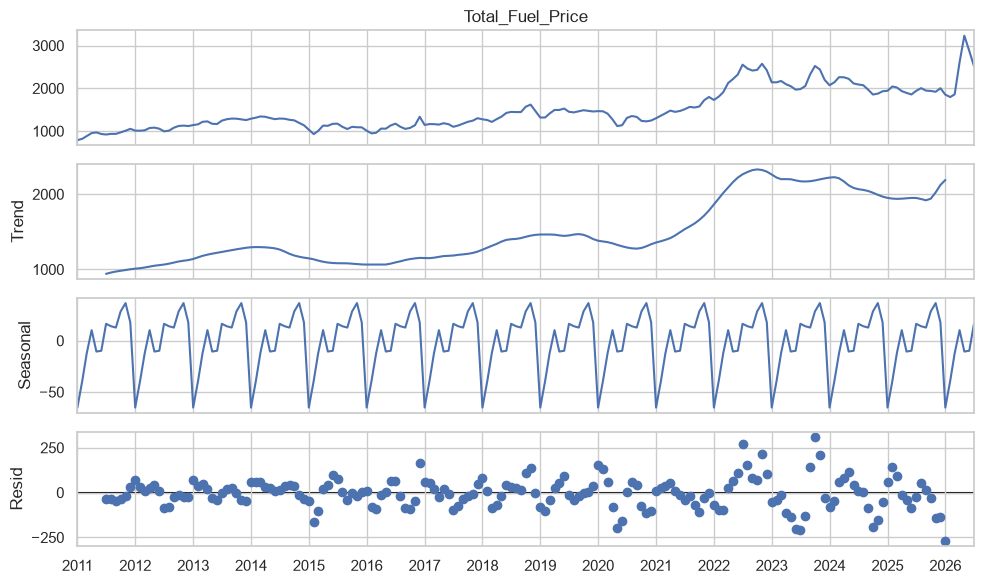

In [39]:
# --- Seasonal decomposition ---
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates

s = master_diesel_df.set_index("Date")["Total_Fuel_Price"].dropna()
result = seasonal_decompose(s, model="additive", period=12)
fig = result.plot()
fig.set_size_inches(10, 6)

for ax in fig.axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

plt.tight_layout()
plt.show()

In [25]:
# --- Correlation with other columns/features ---
corr = master_diesel_df.corr(numeric_only=True)["Total_Fuel_Price"].sort_values(ascending=False)
corr

Total_Fuel_Price            1.000000
BFP                         0.945658
BFP_Lag1                    0.914272
BFP_Lag2                    0.846553
BFP_Lag3                    0.816426
BFP_Lag6                    0.773146
USDZAR_LastWeekMean         0.740722
USDZAR_Mean                 0.738670
USDZAR_LastWeekMean_Lag1    0.733183
USDZAR_Mean_Lag1            0.729922
USDZAR_LastWeekMean_Lag2    0.722224
USDZAR_Mean_Lag2            0.719154
USDZAR_LastWeekMean_Lag3    0.710997
USDZAR_Mean_Lag3            0.710073
BFP_Lag12                   0.631888
GPR_Lag2                    0.622497
GPR_Lag1                    0.611799
GPR_Lag3                    0.588961
GPR                         0.561995
GPR_Lag6                    0.515307
GSCPI_Lag12                 0.469725
GPR_Lag12                   0.415377
INDPRO                      0.385667
INDPRO_Lag1                 0.381927
Brent_LastWeekStd_Lag2      0.369308
Brent_LastWeekStd_Lag1      0.362429
INDPRO_Lag2                 0.355372
I

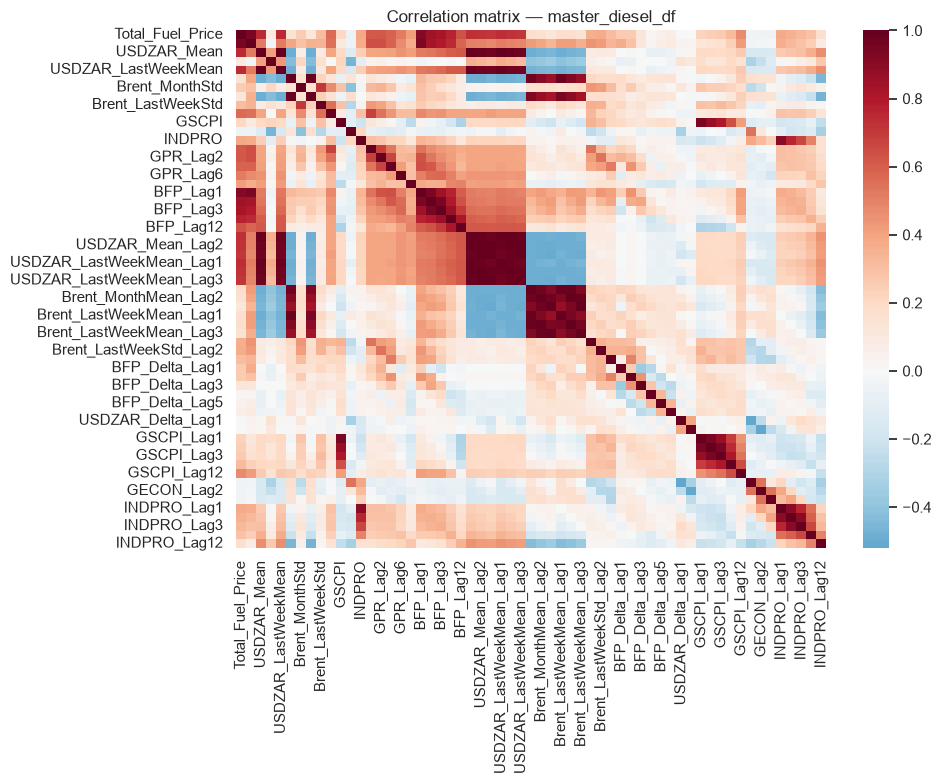

In [26]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(master_diesel_df.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — master_diesel_df")
plt.tight_layout()
plt.show()

In [ ]:
# We want to keep variables that are highly correlated with the target variable, but not too highly correlated with each other. 
# A common threshold for high correlation is 0.8 or -0.8.